# Posterior decomposition of infection routes under the $n=2$ model

This notebook computes the posterior distribution of the total infection probability $p_{jk}$ and of the three route-attribution probabilities defined in the manuscript.

For source host $j$ and target host $k$, let

$$
P_{jk}^{\overline{\mathrm{EST}}}
=
\mathbb{P}(\overline{\mathrm{EST}}),
$$

$$
P_{jk}^{\overline{\mathrm{SV}}}
=
\mathbb{P}(\overline{\mathrm{SV}}),
$$

and

$$
P_{jk}^{\overline{\mathrm{DN}}\mid\overline{\mathrm{EST}}}
=
\mathbb{P}(\overline{\mathrm{DN}}\mid\overline{\mathrm{EST}}).
$$

The total infection probability is

$$
p_{jk}
=
1-
P_{jk}^{\overline{\mathrm{SV}}}
P_{jk}^{\overline{\mathrm{EST}}}
P_{jk}^{\overline{\mathrm{DN}}\mid\overline{\mathrm{EST}}}.
$$

To avoid double counting, infection outcomes are decomposed into the disjoint events

$$
\mathrm{INF}
=
\mathrm{EST}
\mathbin{\dot\cup}
\left(\mathrm{SV}\cap\overline{\mathrm{EST}}\right)
\mathbin{\dot\cup}
\left(\mathrm{DN}\cap\overline{\mathrm{SV}}\cap\overline{\mathrm{EST}}\right).
$$

The corresponding route-attribution probabilities conditional on infection are

$$
C_{jk}^{\mathrm{EST}}
=
\frac{1-P_{jk}^{\overline{\mathrm{EST}}}}{p_{jk}},
$$

$$
C_{jk}^{\mathrm{SV}}
=
\frac{\left(1-P_{jk}^{\overline{\mathrm{SV}}}\right)
P_{jk}^{\overline{\mathrm{EST}}}}{p_{jk}},
$$

and

$$
C_{jk}^{\mathrm{DN}}
=
\frac{\left(1-P_{jk}^{\overline{\mathrm{DN}}\mid\overline{\mathrm{EST}}}\right)
P_{jk}^{\overline{\mathrm{SV}}}
P_{jk}^{\overline{\mathrm{EST}}}}{p_{jk}}.
$$

When $p_{jk}>0$, these three probabilities sum to $1$. 

In [1]:
from pathlib import Path
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, special

# Input and output paths
POSTERIOR_PATH = Path("posterior_n2.pkl")
OUTPUT_DIR = Path("pathway_decomposition_n2_output")
FIGURE_BASENAME = "fig_pathway_decomposition_posterior"
SUMMARY_FILENAME = "pathway_decomposition_posterior_summary.csv"
SAVE_PDF = True

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Posterior file: {POSTERIOR_PATH}")
print(f"Output directory: {OUTPUT_DIR}")


Posterior file: posterior_n2.pkl
Output directory: pathway_decomposition_n2_output


## Load posterior draws

In [2]:
if not POSTERIOR_PATH.exists():
    raise FileNotFoundError(
        f"Posterior file not found: {POSTERIOR_PATH.resolve()}"
    )

with POSTERIOR_PATH.open("rb") as handle:
    posterior = pickle.load(handle)

n_dim = int(posterior["n_dim"])
if n_dim != 2:
    raise ValueError(
        f"This notebook is written for n=2, but the posterior contains n={n_dim}."
    )

chains = posterior.get("chains", [])
if not chains:
    raise ValueError("The posterior object does not contain any MCMC chains.")

samples = np.vstack([np.asarray(chain["samples"]) for chain in chains])
if samples.ndim != 2 or samples.shape[0] == 0:
    raise ValueError("No retained posterior draws were found.")

HOSTS = list(posterior.get("data", {}).get(
    "hosts", ["CH", "LA", "SA", "SO", "ZI"]
))
SOURCES = ["CL"] + HOSTS
H = len(HOSTS)

expected_parameter_count = 1 + H + H + H * n_dim
if samples.shape[1] != expected_parameter_count:
    raise ValueError(
        "Unexpected posterior sample dimension: "
        f"found {samples.shape[1]}, expected {expected_parameter_count}."
    )

n_draws = samples.shape[0]
print(f"Loaded {n_draws:,} retained posterior draws.")
print(f"Model: {posterior.get('model', 'not specified')}")
print(f"Hosts: {HOSTS}")


Loaded 50,000 retained posterior draws.
Model: distance_only_closed_form_with_qk + BetaBinomial(lineage-level)
Hosts: ['CH', 'LA', 'SA', 'SO', 'ZI']


## Compute geometric and rescue quantities

For each posterior draw, the notebook reconstructs the source phenotypes, target optima, scaled growth rates $r_{jk}$, the approximation of $\overline{\Pi}_{jk}$ used in the likelihood, and $\nu_{jk}=2U\overline{\Pi}_{jk}$.

In [3]:
# Unpack parameters
log10_U = samples[:, 0]
U = 10.0 ** log10_U
R = np.exp(samples[:, 1:1 + H])
q = samples[:, 1 + H:1 + 2 * H]
O = samples[:, 1 + 2 * H:].reshape(n_draws, H, n_dim)

# CL is fixed at the origin; the remaining source phenotypes are represented
# by the corresponding host-associated points in the baseline model.
source_points = np.concatenate(
    [np.zeros((n_draws, 1, n_dim)), O],
    axis=1,
)

# Squared distances from each source phenotype to each target optimum.
difference = source_points[:, :, None, :] - O[:, None, :, :]
d2 = np.sum(difference * difference, axis=3)

R_b = R[:, None, :]
q_b = q[:, None, :]
R2 = R_b ** 2


def compute_positive_mutant_growth_term(d2, R_b, n_dim):
    """Matched approximation of the expected positive mutant growth rate."""
    R2 = R_b ** 2

    # Gaussian approximation
    mu = 1.0 - (d2 + n_dim) / R2
    sigma = np.sqrt(
        np.maximum((4.0 * d2 + 2.0 * n_dim) / (R2 * R2), 1e-15)
    )
    z = mu / sigma
    gaussian = np.maximum(
        mu * stats.norm.cdf(z) + sigma * stats.norm.pdf(z),
        0.0,
    )

    # Laplace approximation
    distance = np.sqrt(np.maximum(d2, 0.0))
    laplace = np.full_like(distance, np.inf)
    mask = distance >= 1e-8
    R_full = np.broadcast_to(R_b, distance.shape)

    y = np.empty_like(distance)
    y[mask] = (
        distance[mask]
        + n_dim / (2.0 * R_full[mask])
        - R_full[mask]
    )
    z_laplace = y[mask] / np.sqrt(2.0)
    prefactor = (
        (1.0 / R_full[mask])
        * (R_full[mask] / distance[mask]) ** ((n_dim - 1.0) / 2.0)
    )
    exponential = np.exp(
        -0.5 * (distance[mask] - R_full[mask]) ** 2
    )
    bracket = (
        np.sqrt(2.0 / np.pi)
        - y[mask] * special.erfcx(z_laplace)
    )
    laplace_values = prefactor * exponential * bracket
    laplace[mask] = np.maximum(
        np.where(np.isfinite(laplace_values), laplace_values, np.inf),
        0.0,
    )

    return np.minimum(gaussian, laplace)


r = 1.0 - d2 / R2
Pi_bar = compute_positive_mutant_growth_term(
    d2=d2,
    R_b=R_b,
    n_dim=n_dim,
)
nu = 2.0 * U[:, None, None] * Pi_bar

print(f"Computed arrays with shape {r.shape} = draws x sources x targets.")


Computed arrays with shape (50000, 6, 5) = draws x sources x targets.


## Infection probability and disjoint route attribution

The failure probabilities are evaluated directly from the model equations. The three numerators in the disjoint decomposition are then divided by $p_{jk}$ to obtain $C_{jk}^{\mathrm{EST}}$, $C_{jk}^{\mathrm{SV}}$, and $C_{jk}^{\mathrm{DN}}$.

In [4]:
# Log failure probabilities, evaluated directly from the manuscript equations.
log_P_fail_EST = -2.0 * q_b * np.maximum(r, 0.0)
log_P_fail_SV = -q_b * nu
log_P_fail_DN_given_fail_EST = -q_b * (
    np.sqrt(2.0 * nu + r * r) - np.abs(r)
)

P_fail_EST = np.exp(log_P_fail_EST)
P_fail_SV = np.exp(log_P_fail_SV)
P_fail_DN_given_fail_EST = np.exp(log_P_fail_DN_given_fail_EST)

# Total infection probability. Using expm1 improves numerical accuracy when
# the infection probability is close to zero.
log_P_fail_INF = (
    log_P_fail_EST
    + log_P_fail_SV
    + log_P_fail_DN_given_fail_EST
)
p_INF = -np.expm1(log_P_fail_INF)
p_INF = np.clip(p_INF, 0.0, 1.0)

# Probabilities of the three disjoint infection events.
P_EST = -np.expm1(log_P_fail_EST)
P_SV_and_fail_EST = P_fail_EST * (-np.expm1(log_P_fail_SV))
P_DN_and_fail_SV_and_fail_EST = (
    P_fail_EST
    * P_fail_SV
    * (-np.expm1(log_P_fail_DN_given_fail_EST))
)

# Verify the disjoint decomposition for every posterior draw and host pair.
p_from_decomposition = (
    P_EST
    + P_SV_and_fail_EST
    + P_DN_and_fail_SV_and_fail_EST
)
max_probability_error = float(
    np.max(np.abs(p_from_decomposition - p_INF))
)
print(
    "Maximum absolute error in the disjoint decomposition: "
    f"{max_probability_error:.3e}"
)
if max_probability_error > 1e-10:
    raise RuntimeError(
        "The disjoint route probabilities do not sum to p_INF numerically."
    )

# Route-attribution probabilities conditional on infection.
C_EST = np.divide(
    P_EST,
    p_INF,
    out=np.zeros_like(P_EST),
    where=p_INF > 0.0,
)
C_SV = np.divide(
    P_SV_and_fail_EST,
    p_INF,
    out=np.zeros_like(P_SV_and_fail_EST),
    where=p_INF > 0.0,
)
C_DN = np.divide(
    P_DN_and_fail_SV_and_fail_EST,
    p_INF,
    out=np.zeros_like(P_DN_and_fail_SV_and_fail_EST),
    where=p_INF > 0.0,
)

C_sum = C_EST + C_SV + C_DN
positive_probability = p_INF > 0.0
if np.any(positive_probability):
    max_conditional_error = float(
        np.max(np.abs(C_sum[positive_probability] - 1.0))
    )
else:
    max_conditional_error = 0.0

print(
    "Maximum absolute error in C_EST + C_SV + C_DN: "
    f"{max_conditional_error:.3e}"
)
if max_conditional_error > 1e-10:
    raise RuntimeError(
        "The conditional route-attribution probabilities do not sum to one."
    )


Maximum absolute error in the disjoint decomposition: 3.331e-16
Maximum absolute error in C_EST + C_SV + C_DN: 4.441e-16


## Posterior summaries

In [5]:
def summarize_posterior(draws, quantity):
    rows = []
    for source_index, source in enumerate(SOURCES):
        for target_index, target in enumerate(HOSTS):
            values = draws[:, source_index, target_index]
            rows.append(
                {
                    "quantity": quantity,
                    "source": source,
                    "target": target,
                    "mean": float(np.mean(values)),
                    "median": float(np.median(values)),
                    "q025": float(np.quantile(values, 0.025)),
                    "q975": float(np.quantile(values, 0.975)),
                }
            )
    return rows


summary_rows = []
for quantity, values in [
    ("p_jk", p_INF),
    ("C_EST", C_EST),
    ("C_SV", C_SV),
    ("C_DN", C_DN),
]:
    summary_rows.extend(summarize_posterior(values, quantity))

summary = pd.DataFrame(summary_rows)
summary_path = OUTPUT_DIR / SUMMARY_FILENAME
summary.to_csv(summary_path, index=False)
print(f"Saved posterior summary: {summary_path}")

summary.head(12)


Saved posterior summary: pathway_decomposition_n2_output/pathway_decomposition_posterior_summary.csv


,quantity,source,target,mean,median,q025,q975
0,p_jk,CL,CH,0.967828,0.978152,0.866592,1.000000
1,p_jk,CL,LA,0.769575,0.771828,0.692133,0.831940
2,p_jk,CL,SA,0.537441,0.539654,0.452450,0.610360
3,p_jk,CL,SO,0.012630,0.008482,0.000550,0.047703
4,p_jk,CL,ZI,0.182934,0.168092,0.056928,0.392278
5,p_jk,CH,CH,0.989534,0.991518,0.965197,1.000000
6,p_jk,CH,LA,0.782890,0.783731,0.728102,0.833442
7,p_jk,CH,SA,0.559049,0.558573,0.496033,0.625029
8,p_jk,CH,SO,0.010954,0.009191,0.001185,0.030280
9,p_jk,CH,ZI,0.143750,0.138818,0.061412,0.253620


## Posterior mean route-attribution figure

The first panel shows the posterior mean infection probability $p_{jk}$. The remaining panels show the posterior means of $C_{jk}^{\mathrm{EST}}$, $C_{jk}^{\mathrm{SV}}$, and $C_{jk}^{\mathrm{DN}}$. Each conditional probability is computed within each posterior draw before averaging.

Saved figure: pathway_decomposition_n2_output/fig_pathway_decomposition_posterior.png
Saved figure: pathway_decomposition_n2_output/fig_pathway_decomposition_posterior.pdf


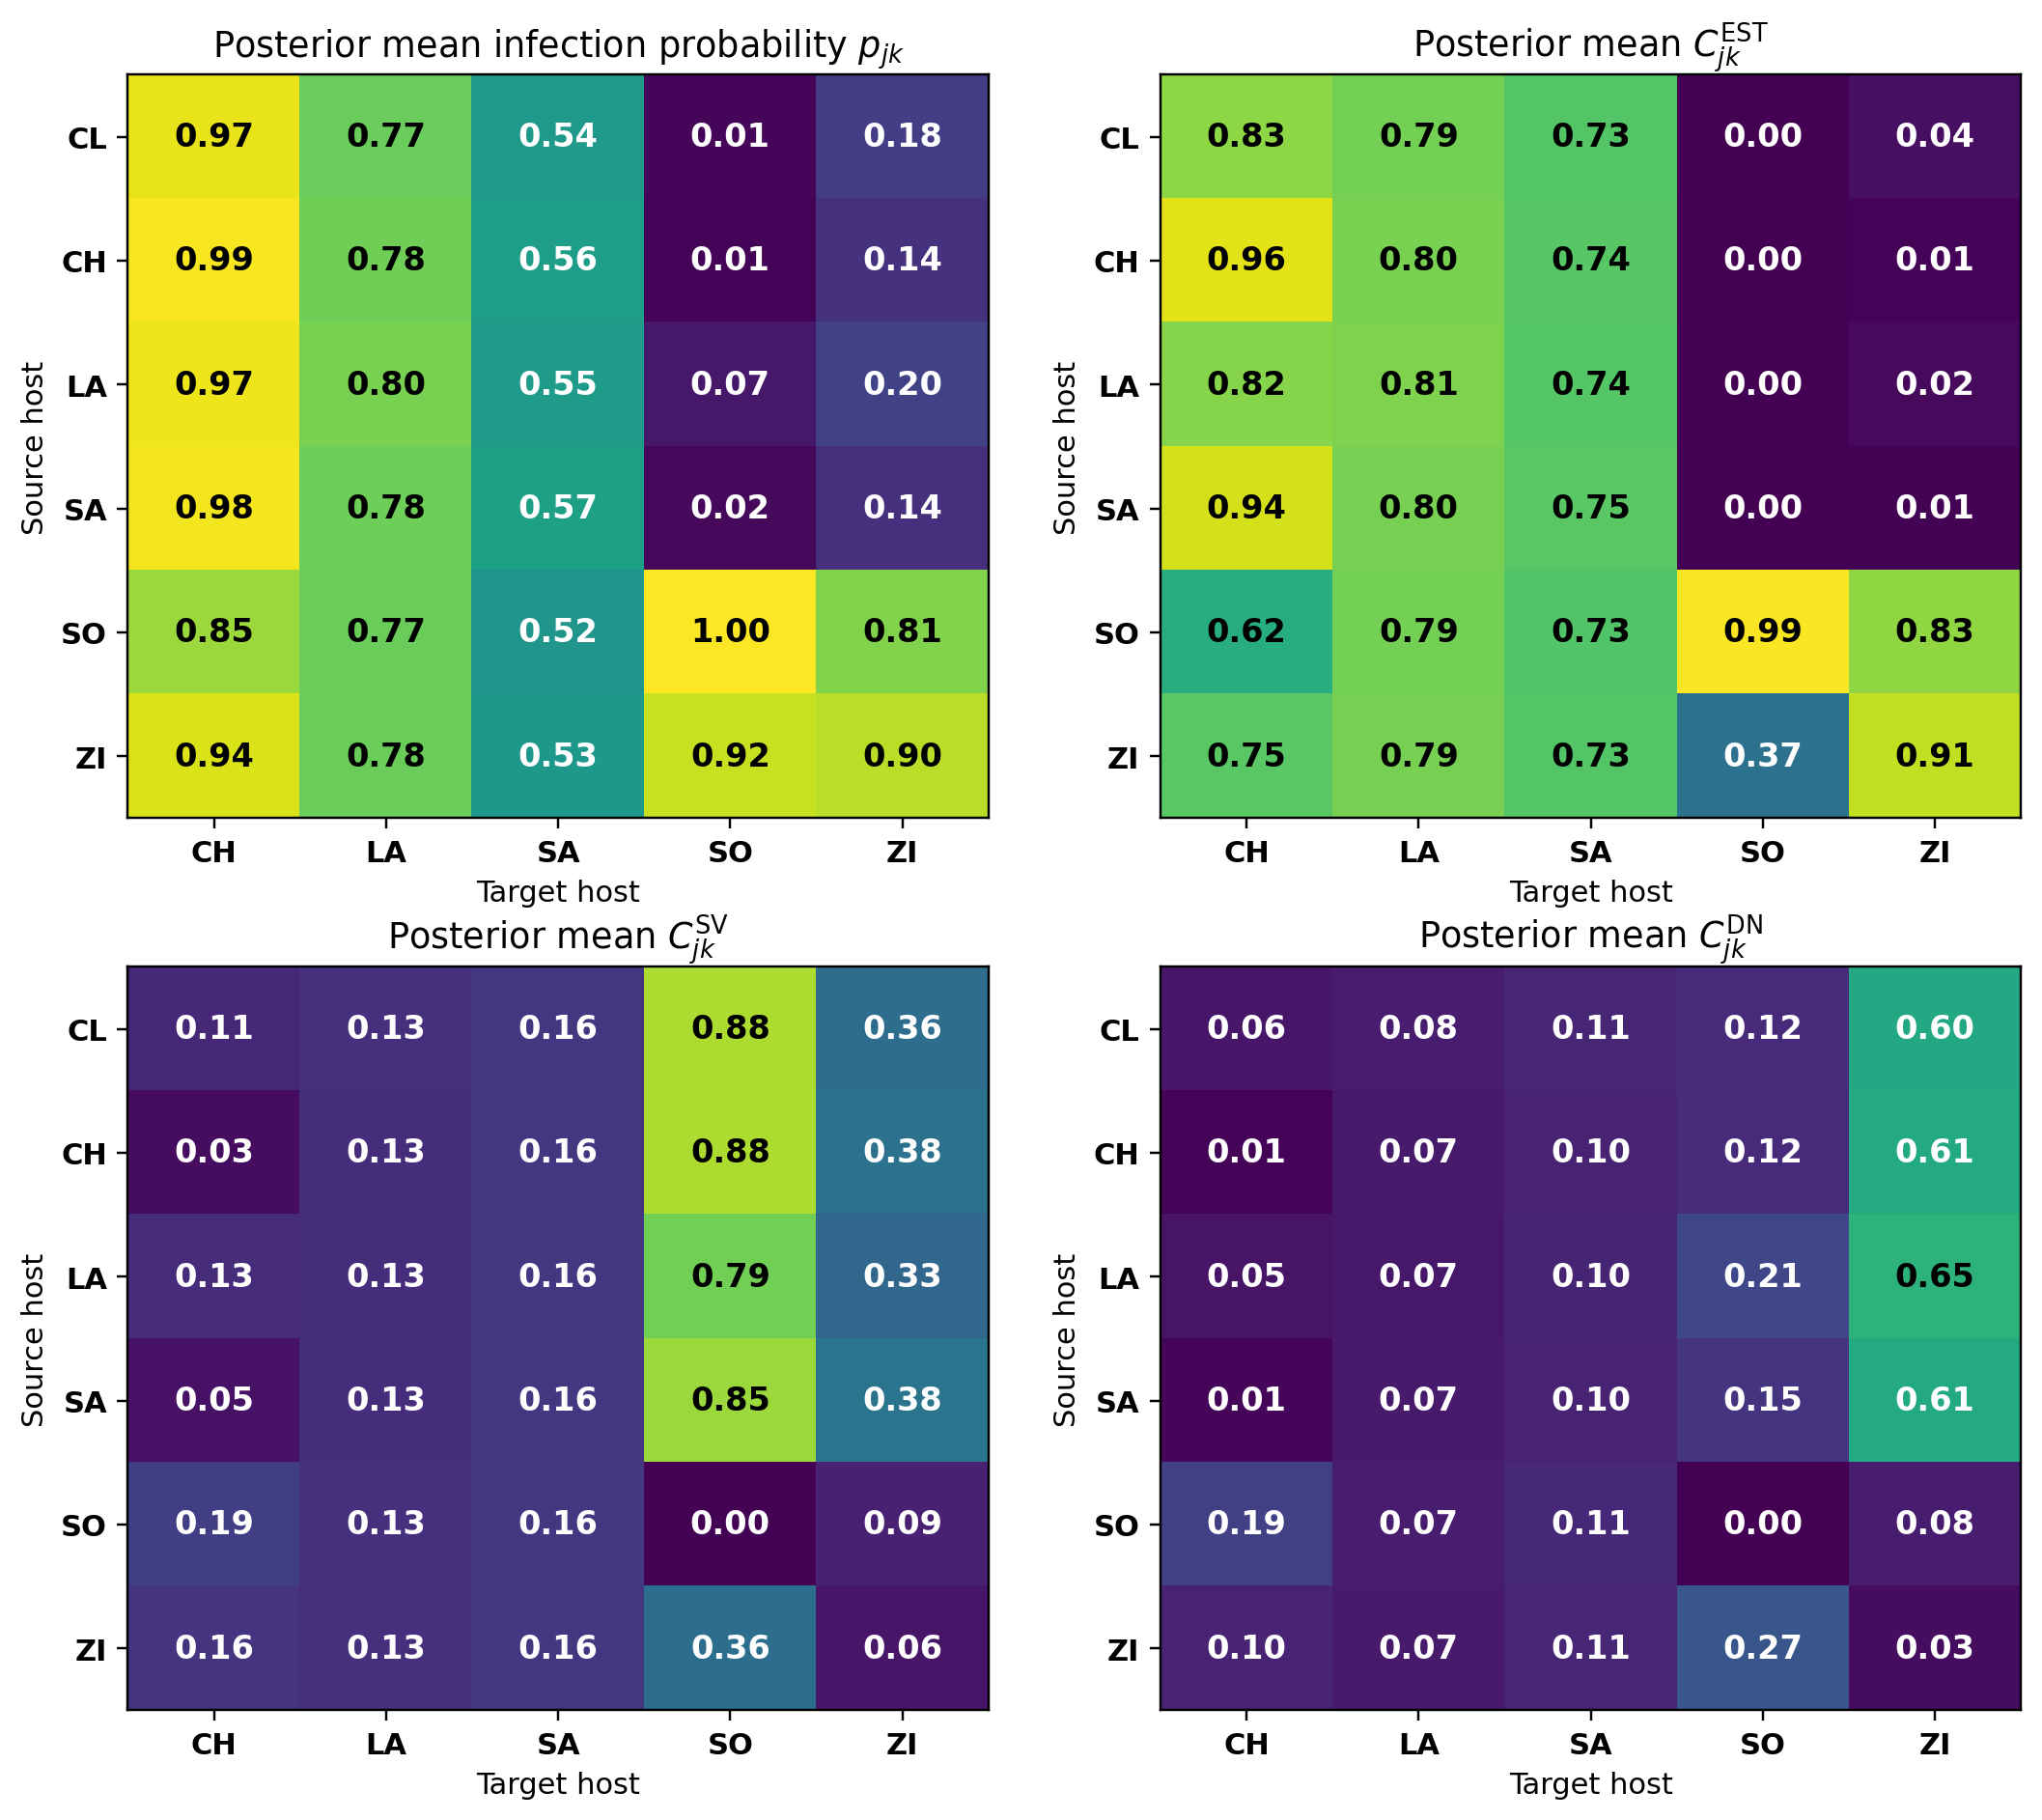

In [7]:
mean_p_INF = np.mean(p_INF, axis=0)
mean_C_EST = np.mean(C_EST, axis=0)
mean_C_SV = np.mean(C_SV, axis=0)
mean_C_DN = np.mean(C_DN, axis=0)


def plot_probability_heatmap(ax, matrix, title):
    image = ax.imshow(
        matrix,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
        aspect="auto",
    )
    ax.set_xticks(range(len(HOSTS)))
    ax.set_xticklabels(HOSTS, fontweight="bold")
    ax.set_yticks(range(len(SOURCES)))
    ax.set_yticklabels(SOURCES, fontweight="bold")
    ax.set_xlabel("Target host")
    ax.set_ylabel("Source host")
    ax.set_title(title)

    for source_index in range(matrix.shape[0]):
        for target_index in range(matrix.shape[1]):
            value = matrix[source_index, target_index]
            text_color = "black" if value > 0.62 else "white"
            ax.text(
                target_index,
                source_index,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=11,
                fontweight="bold",
                color=text_color,
            )
    return image


fig, axes = plt.subplots(2, 2, figsize=(11.5, 10), dpi=220)
axes = axes.ravel()

matrices = [mean_p_INF, mean_C_EST, mean_C_SV, mean_C_DN]
titles = [
    r"Posterior mean infection probability $p_{jk}$",
    r"Posterior mean $C_{jk}^{\mathrm{EST}}$",
    r"Posterior mean $C_{jk}^{\mathrm{SV}}$",
    r"Posterior mean $C_{jk}^{\mathrm{DN}}$",
]

images = [
    plot_probability_heatmap(ax, matrix, title)
    for ax, matrix, title in zip(axes, matrices, titles)
]

#colorbar = fig.colorbar(images[0], ax=axes, fraction=0.025, pad=0.03)
#colorbar.set_label("Probability")

png_path = OUTPUT_DIR / f"{FIGURE_BASENAME}.png"
fig.savefig(png_path, bbox_inches="tight")
print(f"Saved figure: {png_path}")

if SAVE_PDF:
    pdf_path = OUTPUT_DIR / f"{FIGURE_BASENAME}.pdf"
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved figure: {pdf_path}")

plt.show()


## Output files

Running the notebook creates:

- `pathway_decomposition_posterior_summary.csv`, containing posterior means, medians, and 95% credible intervals for $p_{jk}$ and the three $C_{jk}^{m}$;
- `fig_pathway_decomposition_posterior.png`;
- `fig_pathway_decomposition_posterior.pdf` when `SAVE_PDF = True`.